# **UVA DS4002 Project 3 - MET Art Classification**
### Analysis code that trains and validates a keras tensorflow image classification model for MET paintings

**Code Purpose:** Use images from MET API website to train a keras image classification model. The guide/tutorial for image classification used to create this code can be found here: https://www.tensorflow.org/tutorials/images/classification

### **IMPORTANT:** In order for code to run you must download IMAGES.tar.gz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib

In [ ]:
# Load dataset from GitHub URL
dataset_url = "https://raw.githubusercontent.com/dsizzle67/Project3-DS4002/main/DATA/IMAGES.tar.gz"
data_dir = tf.keras.utils.get_file('IMAGES.tar.gz', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).with_suffix('')
print(data_dir)

# Print the number of images
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

/Users/Daria/.keras/datasets/IMAGES_extracted
1416


**NOTE:** replace "/path/to/IMAGES_extracted" with the path to IMAGES_extracted on your machine. The path was printed in the output of the previous code chunk

In [ ]:
# This code finds and deletes and images that begin with "._"
# These files are sometimes created on MacOS when extracting tar.gz files and will cause errors when making the model
!find /path/to/IMAGES_extracted -name "._*" -delete

In [5]:
# Basic loader parameters
batch_size = 32
img_height = 180
img_width = 180

# Load training dataset with an 80-20 split for validation
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 708 files belonging to 4 classes.
Using 567 files for training.


In [6]:
# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Print the class names
class_names = train_ds.class_names
print(class_names)

Found 708 files belonging to 4 classes.


Using 141 files for validation.
['Edo', 'Meiji', 'Other_Periods', 'Qing_Ming']


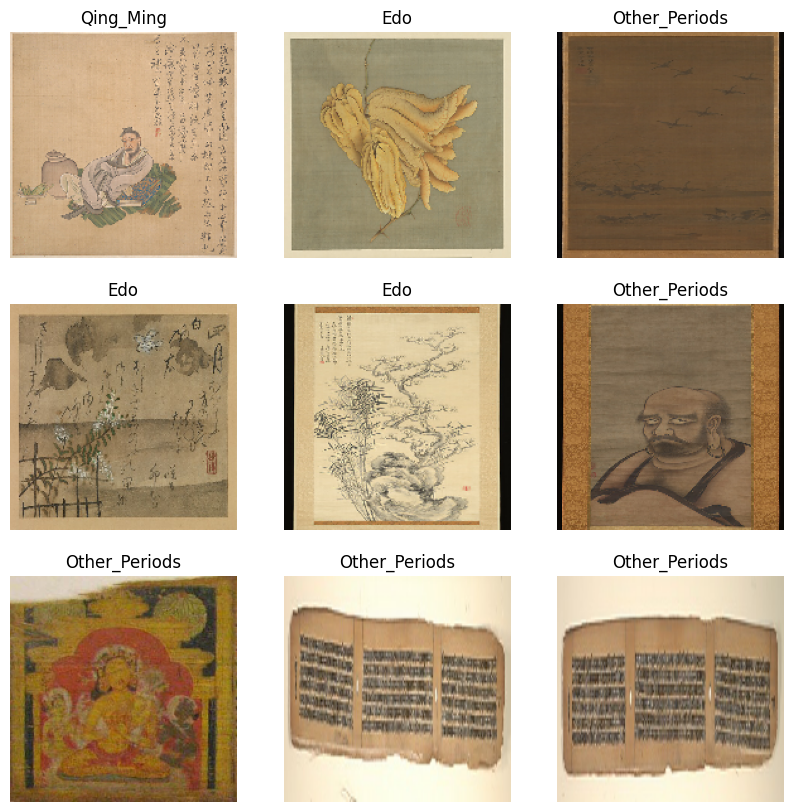

In [7]:
# Display some sample images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# Standardize the pixel values to [0, 1] range
normalization_layer = layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.06111295 0.8870903


In [11]:
# Create the model
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the model with 10 epochs
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.3810 - loss: 1.3113 - val_accuracy: 0.4681 - val_loss: 1.0520
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.4956 - loss: 1.0563 - val_accuracy: 0.5390 - val_loss: 0.9400
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.6032 - loss: 0.9162 - val_accuracy: 0.4752 - val_loss: 1.1044
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.6332 - loss: 0.9007 - val_accuracy: 0.5674 - val_loss: 0.9029
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.6843 - loss: 0.7573 - val_accuracy: 0.6383 - val_loss: 0.8876
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.7601 - loss: 0.6479 - val_accuracy: 0.6525 - val_loss: 0.8187
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.7831 - loss: 0.5745 - val_accuracy: 0.6383 - val_loss: 0.9007
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.7795 - loss: 0.5721 - val_accuracy: 0.

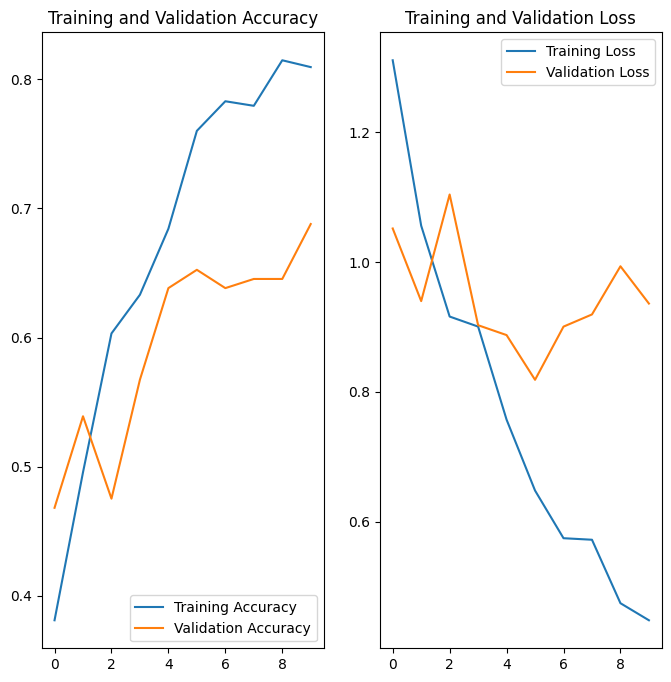

In [ ]:
# Visualize training results for Model 1
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### **Testing Different Epochs**
#### The following code chunks are the same as the previous two cells, but with 20 and 15 epochs. This section can be skipped, you can also change the number of epochs to see different results.

In [20]:
# Train the model with 20 epochs
epochs=20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.7213 - loss: 0.6870 - val_accuracy: 0.5957 - val_loss: 0.9322
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.7213 - loss: 0.6687 - val_accuracy: 0.6383 - val_loss: 0.8548
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.7160 - loss: 0.6669 - val_accuracy: 0.6241 - val_loss: 0.9072
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.7055 - loss: 0.6421 - val_accuracy: 0.6525 - val_loss: 0.9246
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.7319 - loss: 0.6333 - val_accuracy: 0.6667 - val_loss: 0.8779
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.7478 - loss: 0.6379 - val_accuracy: 0.6667 - val_loss: 0.9527
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step - accuracy: 0.7178 - loss: 0.6505 - val_accuracy: 0.6667 - val_loss: 0.8722
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.7637 - loss: 0.5984 - val_accuracy: 0.

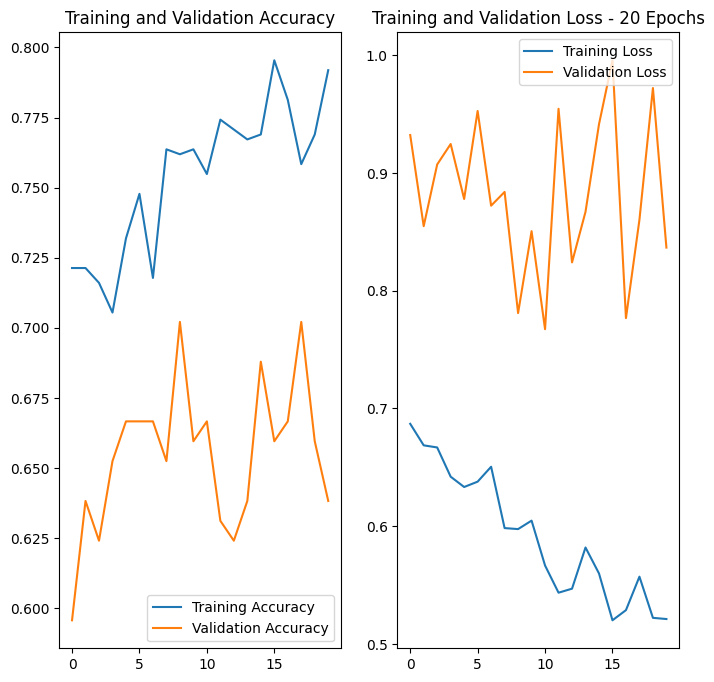

In [ ]:
# Visualize training results
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy - 20 Epochs')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss - 20 Epochs')
plt.show()

In [ ]:
# Train the model with 15 epochs
epochs=15 # Change this number to whatever number you want to test out training the model with different epochs

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.8131 - loss: 0.4486 - val_accuracy: 0.6667 - val_loss: 0.9164
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.8272 - loss: 0.4735 - val_accuracy: 0.6454 - val_loss: 0.9253
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.8131 - loss: 0.4640 - val_accuracy: 0.6312 - val_loss: 0.8894
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.7989 - loss: 0.4404 - val_accuracy: 0.6454 - val_loss: 1.0633
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.7989 - loss: 0.4709 - val_accuracy: 0.6809 - val_loss: 0.8719
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 163ms/step - accuracy: 0.8219 - loss: 0.4301 - val_accuracy: 0.6525 - val_loss: 0.9262
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8254 - loss: 0.4591 - val_accuracy: 0.6809 - val_loss: 0.9710
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8166 - loss: 0.4265 - val_accuracy: 0.

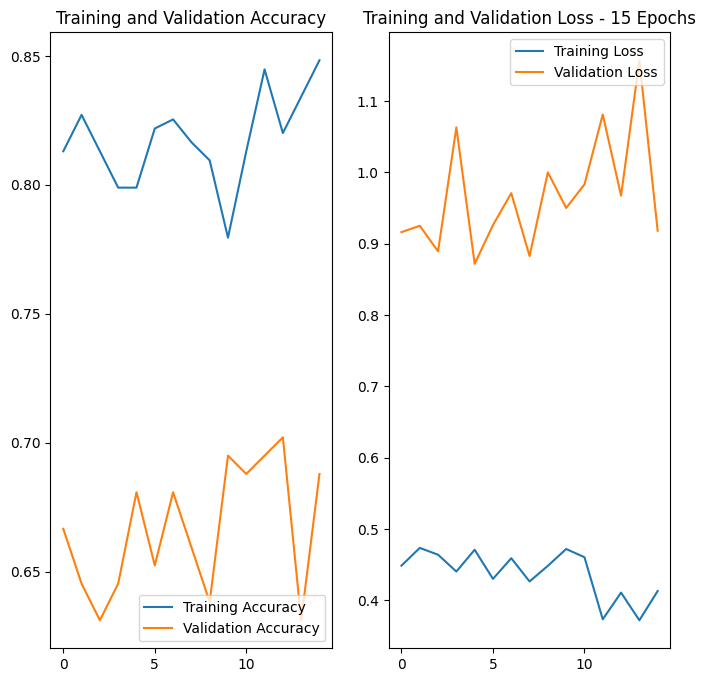

In [ ]:
# Visualize training results
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy - 15 Epochs')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss - 15 Epochs')
plt.show()

### End section **Testing Different Epochs**

### **Data Augmentation**
The following code blocks will use data augmentation to attempt to reduce overfitting.

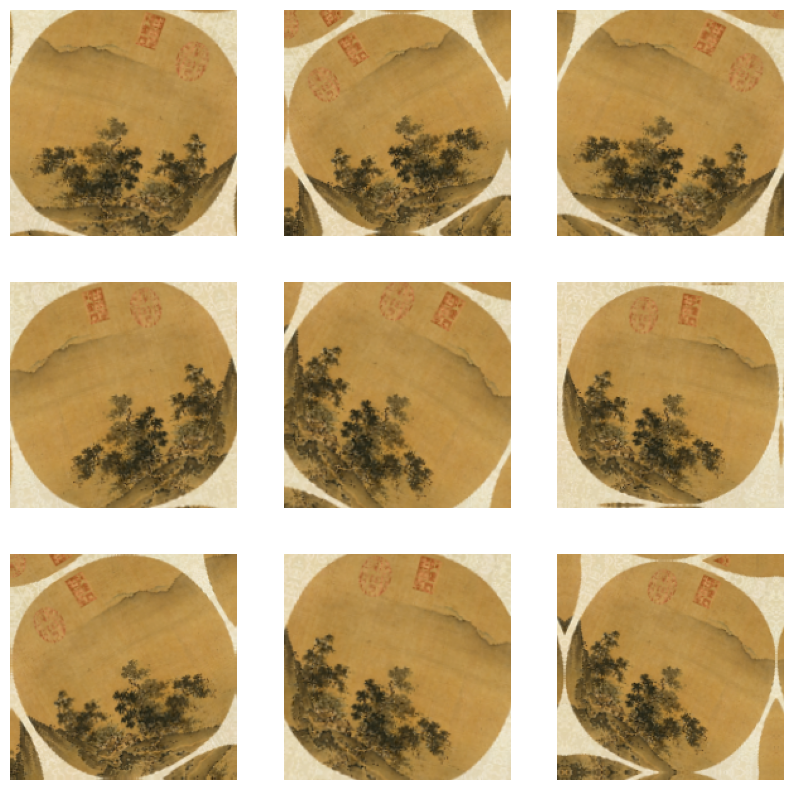

In [26]:
# The following data augmentation code generates additional training data by applying randomw transformations to existing images
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [34]:
# Create the model with data augmentation
model = Sequential([
  data_augmentation, # augemented data layer
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with data augmentation and 15 epochs
epochs = 15 # Change to adjust number of epochs used
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.3527 - loss: 1.4973 - val_accuracy: 0.4397 - val_loss: 1.0325
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.4762 - loss: 1.0866 - val_accuracy: 0.4043 - val_loss: 1.0907
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5185 - loss: 1.0261 - val_accuracy: 0.6099 - val_loss: 0.9485
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.5767 - loss: 0.9809 - val_accuracy: 0.5390 - val_loss: 1.0179
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5908 - loss: 0.9610 - val_accuracy: 0.6099 - val_loss: 0.9300
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5891 - loss: 0.9484 - val_accuracy: 0.5674 - val_loss: 0.9460
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.6367 - loss: 0.8689 - val_accuracy: 0.6383 - val_loss: 0.8769
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.6473 - loss: 0.8227 - val_accuracy: 0.

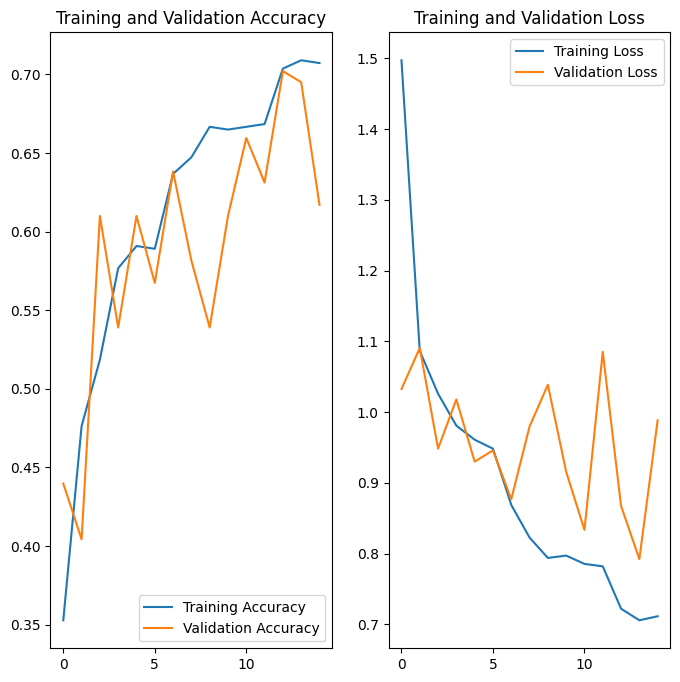

In [ ]:
# Visualize the training results for Model 2
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

After using data augmentation we get some interesting results. The training and validation accuracy drops compared to our non-augmented model (10 epoch model), but training and validation accurcacy results are more similar that pre-augmentation meaning that the data augmentation helped the improve validation accuracy somewhat, with our highest accuracy reach about 70%. Our new model was also able to lower validation loss quite significantly.

### **Dropout** (and data augmentation)
Dropout helps regularize neural networks to reduce overfitting by removing a random selection of numbers from a single gradient step in a layer.

In [ ]:
# Create the model with data augmentation AND dropout
model = Sequential([
  data_augmentation, # augemented data layer
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2), # dropout layer
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with data augmentation, dropout and 15 epochs
epochs = 15 # Change to adjust number of epochs used
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.4039 - loss: 1.2804 - val_accuracy: 0.4184 - val_loss: 1.0461
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.5291 - loss: 1.0736 - val_accuracy: 0.5390 - val_loss: 1.0135
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.5485 - loss: 0.9911 - val_accuracy: 0.5674 - val_loss: 0.9449
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.5908 - loss: 0.9253 - val_accuracy: 0.5461 - val_loss: 0.9470
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.6067 - loss: 0.8966 - val_accuracy: 0.6312 - val_loss: 0.9047
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.6332 - loss: 0.8539 - val_accuracy: 0.5887 - val_loss: 0.9262
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.6279 - loss: 0.8393 - val_accuracy: 0.6099 - val_loss: 1.0193
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.6896 - loss: 0.8024 - val_accuracy: 0.

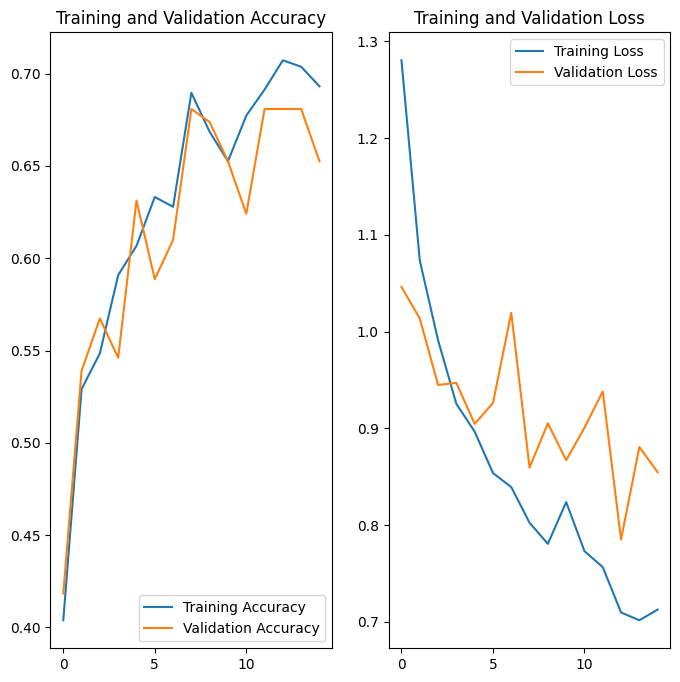

In [ ]:
# Visualize training results for Model 3
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

This model performed similarly to the data augmentation model without dropout, although it does have a lower max validation accuracy.